In [32]:
import os
import itertools
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
from tqdm import tqdm
# from IPython.display import clear_output

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
from torch import nn
import torch.nn.functional as F

from kan import KAN
from kan import ex_round

# import folium
# from branca.element import MacroElement, Element
from jinja2 import Template

import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [5]:
def add_features(df, target_col='pm25', threshold=35, horizon=1, wind_limit=1.5):
    """
    Адаптированная подготовка датасета с учетом вертикального профиля атмосферы 
    и динамической устойчивости (число Ричардсона).
    """
    data = df.copy()
    eps = 1e-5  # Защита от деления на 0
    g = 9.81    # Ускорение свободного падения

    # ВЕРТИКАЛЬНАЯ ИНВЕРСИЯ
    inv_180_2 = data['temperature_180m (°C)'] - data['temperature_2m (°C)']
    inv_120_2 = data['temperature_120m (°C)'] - data['temperature_2m (°C)']
    inv_80_2 = data['temperature_80m (°C)'] - data['temperature_2m (°C)']

    data['max_inv'] = np.max([inv_80_2, inv_120_2, inv_180_2],axis=0)
    data['mean_inv'] = np.mean([inv_80_2, inv_120_2, inv_180_2],axis=0)
    data['grad_80_180_inv'] = inv_80_2 - inv_180_2
    data['inv_height'] = np.argmax([inv_80_2, inv_120_2, inv_180_2],axis=0)

    # Функция для расчета Ri между двумя высотами
    def calc_bulk_richardson_number(
        t_low, t_high,
        wind_speed_low, wind_dir_low,
        wind_speed_high, wind_dir_high,
        h_low, h_high
    ):
        """
        Bulk Richardson number между двумя уровнями.
    
        Вход:
        - t_low, t_high: температура (°C)
        - wind_speed_low/high: скорость ветра (m/s)
        - wind_dir_low/high: направление ветра (°)
        - h_low, h_high: высоты (m)
    
        Выход:
        - Ri_b: Bulk Richardson number
        """
    
        g = 9.81
    
        # --- высоты ---
        dz = h_high - h_low
    
        # --- температура (переход в K) ---
        theta_low = t_low + 273.15
        theta_high = t_high + 273.15
        theta_mean = (theta_low + theta_high) / 2.0
    
        dtheta = theta_high - theta_low
    
        # --- ветер: перевод в u,v ---
        def wind_to_uv(speed, direction_deg):
            rad = np.radians(direction_deg)
            u = speed * np.sin(rad)
            v = speed * np.cos(rad)
            return u, v
    
        u_low, v_low = wind_to_uv(wind_speed_low, wind_dir_low)
        u_high, v_high = wind_to_uv(wind_speed_high, wind_dir_high)
    
        # --- shear ---
        du = u_high - u_low
        dv = v_high - v_low
    
        shear = du**2 + dv**2
    
        # защита от деления на ноль / штиля
        shear = np.where(shear < 0.0001, 0.0001, shear)
    
        # --- Bulk Ri ---
        ri = (g / theta_mean) * (dtheta * dz) / shear
    
        return ri
    
    # Числа Ричардсона
    Ri_2_180 = calc_bulk_richardson_number(
        data['temperature_2m (°C)'], data['temperature_180m (°C)'],
        data['wind_speed_10m (m/s)'], data['wind_direction_10m (°)'],
        data['wind_speed_180m (m/s)'], data['wind_direction_180m (°)'],
        2, 180
    )
    Ri_2_120 = calc_bulk_richardson_number(
        data['temperature_2m (°C)'], data['temperature_120m (°C)'],
        data['wind_speed_10m (m/s)'], data['wind_direction_10m (°)'],
        data['wind_speed_120m (m/s)'], data['wind_direction_120m (°)'],
        2, 120
    )
    Ri_2_80 = calc_bulk_richardson_number(
        data['temperature_2m (°C)'], data['temperature_80m (°C)'],
        data['wind_speed_10m (m/s)'], data['wind_direction_10m (°)'],
        data['wind_speed_80m (m/s)'], data['wind_direction_80m (°)'],
        2, 80
    )

    data['max_Ri'] = np.max([Ri_2_80, Ri_2_120, Ri_2_180],axis=0)
    data['mean_Ri'] = np.mean([Ri_2_80, Ri_2_120, Ri_2_180],axis=0)
    data['grad_80_180_Ri'] = Ri_2_80 - Ri_2_180
    
    # Кодирование цикличных признаков
    # data['sin_month'] = np.sin(2 * np.pi * data['month'] / 12)
    # data['cos_month'] = np.cos(2 * np.pi * data['month'] / 12)
    # data['sin_hour'] = np.sin(2 * np.pi * data['hour'] / 24)
    # data['cos_hour'] = np.cos(2 * np.pi * data['hour'] / 24)
    # data['sin_DOY'] = np.sin(2 * np.pi * data['day_of_year'] / 365)
    # data['cos_DOY'] = np.cos(2 * np.pi * data['day_of_year'] / 365)

    data['sin_wind_direction_10m'] = np.sin(2 * np.pi * data['wind_direction_10m (°)'] / 360)
    data['cos_wind_direction_10m'] = np.cos(2 * np.pi * data['wind_direction_10m (°)'] / 360)

    data['wind_shear'] = data['wind_speed_180m (m/s)'] - data['wind_speed_10m (m/s)']

    del_cols = ['month', 'hour', 'day_of_year','wind_direction_10m (°)',
                'wind_direction_80m (°)','wind_direction_120m (°)','wind_direction_180m (°)']
    data = data.drop(del_cols, axis=1)
    
    return data.dropna()


def add_rolling_features(df, cols):
    data = df.copy()

    for col in cols:
        # data[col+'_roll4'] = data[col].rolling(window=4).mean()
        # data[col+'_roll8'] = data[col].rolling(window=8).mean()
        # data[col+'_roll12'] = data[col].rolling(window=12).mean()
        data[col+'_roll24'] = data[col].rolling(window=24).mean()

    return data.dropna()

In [6]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

def calculate_smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def get_regression_metrics(y_true, y_pred, to_numpy=True):
    # Переводим в numpy для расчета стандартных метрик
    if to_numpy:
        y_true = y_true.cpu().numpy()
        y_pred = y_pred.cpu().numpy()

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    smape = calculate_smape(y_true, y_pred) / 100 # Приводим к формату из твоего скриншота
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    
    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'SMAPE': smape,
        'Corr': corr
    }

def train_step(model, train_input, train_label, optimizer, criterion, lamb=1e-4, update=True):
    model.train()
    def closure():
        optimizer.zero_grad()
        
        pred = F.sigmoid(model(train_input))
        loss = criterion(pred, train_label)
        reg_loss = model.reg('edge_forward_spline_n',1.0,1.0,1.0,1.0)
        total_loss = loss + lamb * reg_loss
        total_loss.backward()
        
        return total_loss

    optimizer.step(closure)
    if update:
        # print('Обновление сетки')
        model.update_grid_from_samples(train_input)

def train(model, dataset, epochs, path, optimizer, criterion, scheduler, 
          lamb=0.0001, patience=10, freq_update=1, name='', progress=True):
    
    best_loss = float('inf')
    best_model = None
    patience_counter = 0
    epoch_flag = 0

    lr_stat = []
    train_metrics_history = []
    val_metrics_history = []

    train_loop = tqdm(range(epochs), leave=False) if progress else range(epochs)

    for epoch in train_loop:
        if freq_update == 0:
            grid_update_flag = False 
        else:    
            grid_update_flag = (epoch + 1) % freq_update == 0
            
        train_step(model, dataset['train_input'], dataset['train_label'], optimizer, criterion, lamb, grid_update_flag)
        
        model.eval()
        with torch.no_grad():
            train_pred = F.sigmoid(model(dataset['train_input']))
            val_pred = F.sigmoid(model(dataset['val_input']))

            train_loss = criterion(train_pred, dataset['train_label'])
            val_loss = criterion(val_pred, dataset['val_label'])

            curr_train_metrics = get_regression_metrics(dataset['train_label'], train_pred)
            curr_train_metrics['Loss'] = train_loss.item()
            
            curr_val_metrics = get_regression_metrics(dataset['val_label'], val_pred)
            curr_val_metrics['Loss'] = val_loss.item()
            
            train_metrics_history.append(curr_train_metrics)
            val_metrics_history.append(curr_val_metrics)

            if progress:
                train_loop.set_description(f"Epoch {epoch+1}| Train R2: {curr_train_metrics['R2']:.4f} | Val R2: {curr_val_metrics['R2']:.4f}")

            scheduler.step(val_loss)
            lr_stat.append(optimizer.param_groups[0]['lr'])

            if val_loss.item() < best_loss:
                best_loss = val_loss.item()
                best_model = model.copy()
                torch.save(best_model.state_dict(), f"{path}/model_{name}.pth")
                patience_counter = 0
                epoch_flag = epoch
            else:
                patience_counter += 1

            if patience_counter >= patience:
                break
                
    best_model.eval()
    with torch.no_grad():
        test_pred = F.sigmoid(best_model(dataset['test_input']))
        test_metrics = get_regression_metrics(dataset['test_label'], test_pred)
        test_metrics['Loss'] = criterion(test_pred, dataset['test_label']).item()
        
    print(f"Epoch {epoch+1}| Train R2: {curr_train_metrics['R2']:.4f} | Val R2: {curr_val_metrics['R2']:.4f}")
    
    return best_model, train_metrics_history, val_metrics_history, test_metrics, epoch_flag

In [36]:
def recursive_integrator(K, data, horizon=24):
    preds = []
    pm = data['pm25'].values
    Q = data['Q_daily'].values
    
    current_val = pm[0]
    
    for i in range(len(K)):
        if i % horizon == 0:
            current_val = pm[i]
            
        # Твоя физическая логика: фон b подвержен метеорологическому выветриванию
        next_val = K[i] * (current_val + Q[i])
        
        preds.append(next_val)
        current_val = next_val
        
    return preds

In [7]:
weather_cols = [
    'time',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)', 'pressure_msl (hPa)',
    'surface_pressure (hPa)', 'temperature_80m (°C)',
    'temperature_120m (°C)', 'temperature_180m (°C)',
    'wind_speed_10m (m/s)', 'wind_speed_80m (m/s)', 'wind_speed_120m (m/s)',
    'wind_speed_180m (m/s)', 'wind_direction_10m (°)',
    'wind_direction_80m (°)', 'wind_direction_120m (°)',
    'wind_direction_180m (°)','precipitation (mm)', 
    'shortwave_radiation (W/m²)'
]

In [27]:
df = pd.read_csv('../data/raw/open_meteo_train.csv')
df['time'] = pd.to_datetime(df['time'])

group = df[(df["site"]==3843)|(df["site"]==3853)|(df["site"]==3842)]
hourly_avg = group.groupby('time')['pm25'].mean()
weather = df[df["site"]==3858][weather_cols]

mean_data = pd.merge(weather, hourly_avg, on="time")

mean_data['month'] = mean_data['time'].dt.month
mean_data['hour'] = mean_data['time'].dt.hour
mean_data['day_of_year'] = mean_data['time'].dt.day_of_year

q_daily_map = mean_data.groupby(['hour'])['pm25'].mean().reset_index()
q_daily_map.rename(columns={'pm25': 'Q_daily'}, inplace=True)
mean_data = pd.merge(mean_data, q_daily_map, on=['hour'], how='left')

mean_data['K'] = mean_data['pm25'] / (mean_data['pm25'].shift(1) + mean_data['Q_daily'])
mean_data = mean_data.dropna()

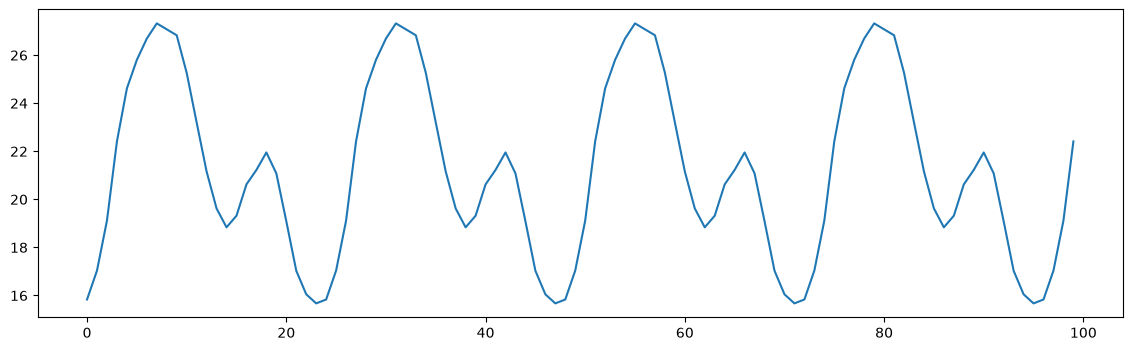

In [29]:
plt.figure(figsize=(14,4))
plt.plot(mean_data['Q_daily'].values[:100])
plt.show()

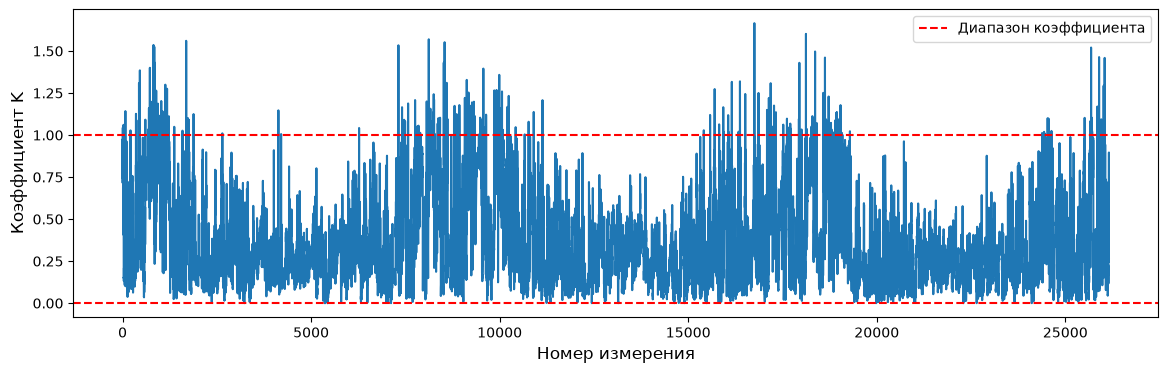

In [28]:
plt.figure(figsize=(14,4))
plt.plot(mean_data['K'])
plt.xlabel('Номер измерения',fontsize=12)
plt.ylabel('Коэффициент K',fontsize=12)
plt.axhline(1.0,linestyle='--',color='red',label='Диапазон коэффициента')
plt.axhline(0.0,linestyle='--',color='red')
plt.legend()
plt.show()

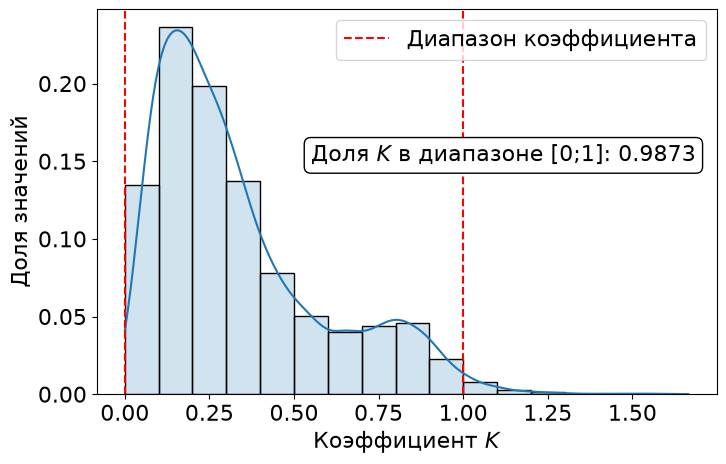

In [33]:
k = int(round(1+3.322*np.log10(mean_data['K'].shape[0]),0))
h = round((np.max(mean_data['K']) - np.min(mean_data['K'])) / k,1)
x0 = np.min(mean_data['K'])
bins = [x0 + h*i for i in range(k+1)]

plt.figure(figsize=(8,5))
sns.histplot(mean_data['K'],bins=bins,stat='probability', alpha=0.2, kde=True)
# sns.histplot(mean_data['K'],bins=bins,stat='probability',fill=False,element='poly',color='black',kde=True)
plt.ylabel('Доля значений',fontsize=16)
plt.xlabel(f'Коэффициент $K$',fontsize=16)
plt.axvline(1.0,linestyle='--',color='red',label='Диапазон коэффициента')
plt.axvline(0.0,linestyle='--',color='red')

K_prob = (mean_data[(mean_data['K'] >= 0) & (mean_data['K'] <= 1)]['K'].count()/mean_data.shape[0]).round(4)
# plt.text(0.8,0.150, )
plt.text(0.55,0.150, f"Доля $K$ в диапазоне [0;1]: {K_prob}", fontsize=16,
         bbox=dict(boxstyle="round",
                   # color='white',
                   facecolor='white',
                   alpha=1
                   # ec=(1., 0.5, 0.5),
                   # fc=(1., 0.8, 0.8),
                   )
         )

plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [34]:
advanced_data = add_features(mean_data)

roll_cols = [
    'temperature_2m (°C)', 'relative_humidity_2m (%)',
    'surface_pressure (hPa)',
    'wind_speed_10m (m/s)', 'precipitation (mm)',
    'shortwave_radiation (W/m²)', 'max_inv',
    'mean_inv', 'grad_80_180_inv', 'inv_height', 'max_Ri', 'mean_Ri',
    'grad_80_180_Ri','wind_shear'
]

final_data = add_rolling_features(advanced_data,roll_cols)

physics_cols = [
    'time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
    'surface_pressure (hPa)', 
    'wind_speed_10m (m/s)', 'precipitation (mm)',
    'shortwave_radiation (W/m²)', 'max_inv','max_Ri',
    'sin_wind_direction_10m', 'cos_wind_direction_10m',
    'wind_shear', 'temperature_2m (°C)_roll24',
    'relative_humidity_2m (%)_roll24', 'surface_pressure (hPa)_roll24',
    'wind_speed_10m (m/s)_roll24', 'precipitation (mm)_roll24',
    'shortwave_radiation (W/m²)_roll24', 'max_inv_roll24',
    'max_Ri_roll24',
    'wind_shear_roll24', 'K'
]

physics_data = final_data[physics_cols]

physics_data = physics_data.set_index(['time'],drop=True)

X = physics_data.drop(['K'], axis=1)
y = physics_data[['K']]

X_train, y_train = X[X.index.year == 2023], y[y.index.year == 2023]
X_val, y_val = X[X.index.year == 2024], y[y.index.year == 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

In [35]:
param_grid = {
    'n_estimators': [10, 50, 100, 150, 200],
    'max_depth': [6, 10, 15, None],
    'min_samples_leaf': [4, 8, 15],
    'max_features': ['sqrt', 'log2', 0.25, 0.4]
}

keys, values = zip(*param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_r2_val = -float('inf')
best_params = None
results_history = []

print(f"Запуск перебора {len(experiments)} комбинаций...")

for params in tqdm(experiments):
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    
    rf.fit(X_train, y_train)
    
    preds_train = rf.predict(X_train)
    preds_val = rf.predict(X_val)
    
    r2_train = r2_score(y_train, preds_train)
    r2_val = r2_score(y_val, preds_val)
    
    results_history.append({
        'params': params,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'gap': r2_train - r2_val
    })
    
    if r2_val > best_r2_val:
        best_r2_val = r2_val
        best_params = params

print("\n=== ОПТИМИЗАЦИЯ ЗАВЕРШЕНА ===")
print(f"Лучшие параметры: {best_params}")
print(f"Максимальный R2 на Валидации: {best_r2_val:.4f}")

Запуск перебора 240 комбинаций...


100%|██████████| 240/240 [03:36<00:00,  1.11it/s]


=== ОПТИМИЗАЦИЯ ЗАВЕРШЕНА ===
Лучшие параметры: {'n_estimators': 150, 'max_depth': None, 'min_samples_leaf': 8, 'max_features': 0.25}
Максимальный R2 на Валидации: 0.5798


In [37]:
best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])
best_rf.fit(X_train, y_train)

r2_final_test = r2_score(y_test, best_rf.predict(X_test))
print(f"R2 финальной архитектуры на тесте: {r2_final_test:.4f}")

R2 финальной архитектуры на тесте: 0.5743


In [38]:
result = permutation_importance(
    best_rf, X_train, y_train, 
    scoring='r2', 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

In [39]:
# Формируем итоговый топ
verification_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

In [40]:
rf_r2 = []
feat_num = []

for feat_i in range(1,21):
    print(feat_i,end=' ')
    model = RandomForestRegressor(**best_params)
    feats = verification_df['Feature'].iloc[:feat_i]
    model.fit(X_train[feats],y_train)
    val_pred = model.predict(X_val[feats])
    
    rf_r2.append(r2_score(y_val,val_pred))
    feat_num.append(feat_i)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 

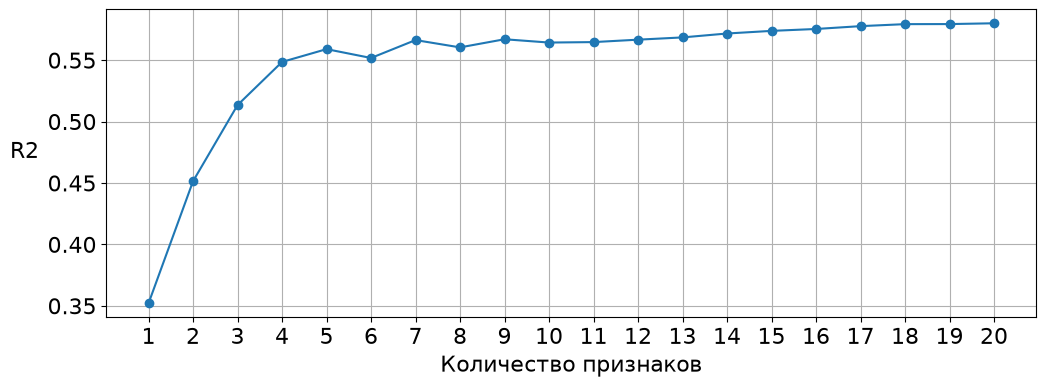

In [41]:
plt.figure(figsize=(12,4))
plt.plot(feat_num, rf_r2,'o-')
plt.xlabel('Количество признаков',fontsize=16)
plt.ylabel('R2     ',fontsize=16,rotation=0)
plt.xticks(feat_num[::1],fontsize=16)
plt.yticks(fontsize=16)
plt.grid()
plt.show()

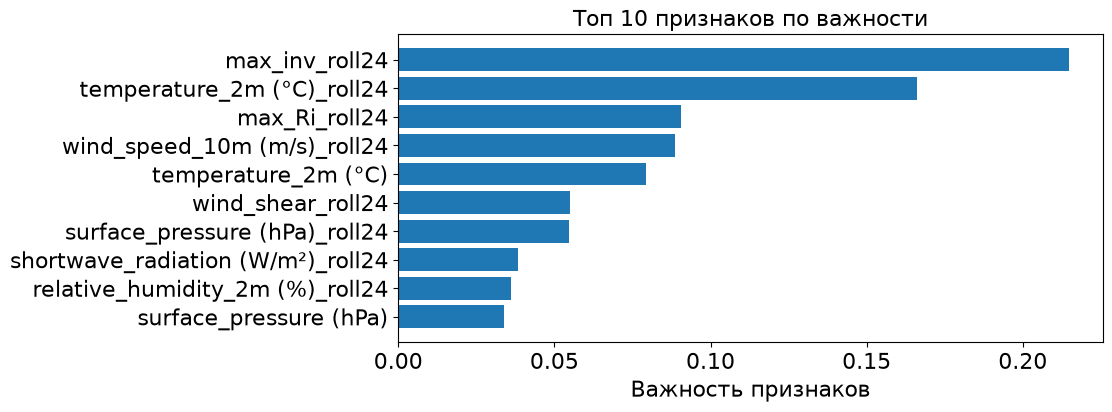

In [42]:
plt.figure(figsize=(20,4))

plt.subplot(1,2,1)
plt.title('Топ 10 признаков по важности', fontsize=16)
plt.xlabel('Важность признаков',fontsize=16)
plt.barh(verification_df['Feature'].iloc[:10][::-1],verification_df['Importance_Mean'].iloc[:10][::-1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [43]:
best_rf.fit(X_train[verification_df['Feature'].iloc[:5]], y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.25
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

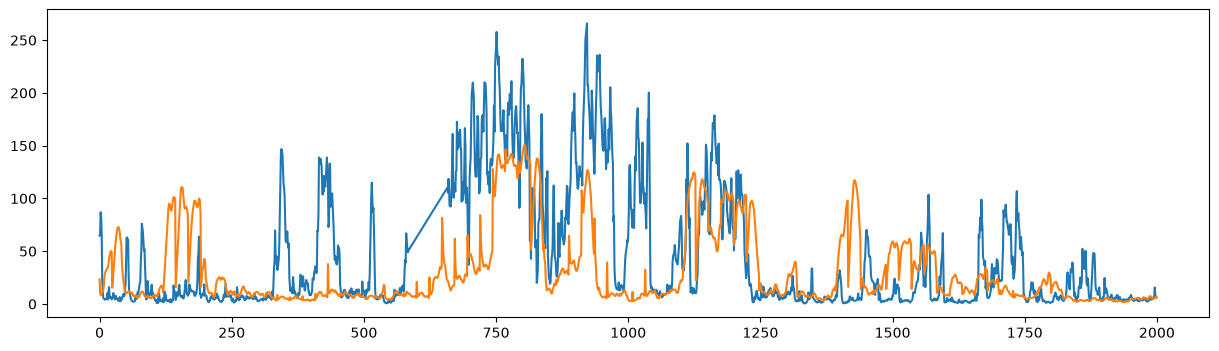

In [49]:
test_pred = best_rf.predict(X_test[verification_df['Feature'].iloc[:5]])
rec_pred = recursive_integrator(test_pred,final_data,24)

plt.figure(figsize=(15,4))
plt.plot(final_data['pm25'].values[:2000])
plt.plot(rec_pred[:2000])
# plt.plot(KAN_K[6000:20000]*100)
plt.show()